# imports

In [1]:
import numpy as np
import pandas as pd
import hypertools as hyp
import nibabel as nb
import nilearn as nl
import supereeg as se
import pickle
import os
import cortex
from cortex import mni
#import neurosynth as ns
from scipy.spatial.distance import cdist
from scipy.stats import pearsonr
import importlib.util as importer
import matplotlib.pyplot as plt

%matplotlib inline

# set paths

In [2]:
# annot_dir = '../../data/annotations_dfs/'
# ep_model_dir = '../../data/models/episodes/'
# ep_traj_dir = os.path.join(ep_model_dir, 't100_w50/', 'trajectories')
# ep_seg_dir = os.path.join(ep_model_dir, 't100_w50/', 'events')
# ep_emb_dir = os.path.join(ep_model_dir, 't100_w50/', 'embeddings', 'k:1000')
# rec_model_dir = '../../data/models/participants/'
# rec_traj_dir = os.path.join(rec_model_dir, 'trajectories')
# rec_seg_dir = os.path.join(rec_model_dir, 'events', 'k:1000')
# rec_emb_dir = os.path.join(rec_model_dir, 'embeddings', 'k:1000')
# pickle_dir = '../../data/pickles/'
# braindata_dir = '../../data/brains/'
# fig_dir = '../../figures/'
# brainfig_dir = os.path.join(fig_dir,'brains/')

In [8]:
annot_dir = '/Users/paxtonfitzpatrick/Desktop/memory-dynamics-data-old/annotations_dfs/'
ep_model_dir = '/Users/paxtonfitzpatrick/Desktop/memory-dynamics-data-old/models/episodes/'
ep_traj_dir = os.path.join(ep_model_dir, 't100_w50/', 'trajectories')
ep_seg_dir = os.path.join(ep_model_dir, 't100_w50/', 'events')
ep_emb_dir = os.path.join(ep_model_dir, 't100_w50/', 'embeddings', 'k:1000')
rec_model_dir = '/Users/paxtonfitzpatrick/Desktop/memory-dynamics-data-old/models/participants/'
rec_traj_dir = os.path.join(rec_model_dir, 'trajectories')
rec_seg_dir = os.path.join(rec_model_dir, 'events', 'k:1000')
rec_emb_dir = os.path.join(rec_model_dir, 'embeddings', 'k:1000')
pickle_dir = '/Users/paxtonfitzpatrick/Desktop/memory-dynamics-data-old/pickles/'
braindata_dir = '/Users/paxtonfitzpatrick/Desktop/memory-dynamics-data-old/brains/'
fig_dir = '/Users/paxtonfitzpatrick/Desktop/memory-dynamics-data-old/figures/'
brainfig_dir = os.path.join(fig_dir,'brains/')

# load data

In [9]:
#
with open(pickle_dir+'fit_models.p', 'rb') as f:
    models_dict = pickle.load(f)
    
brainweights = np.load(braindata_dir+'HuthModelWeights.npy')
mask = np.load(braindata_dir+'mask.npy')

away_from_topics = np.load(braindata_dir+'away_from_topic_vector.npy')
toward_topics = np.load(braindata_dir+'toward_topic_vector.npy')
    
#ns_dataset = ns.base.dataset.Dataset.load(pickle_dir+'neurosynth_dataset.p')

# episode trajectories
episode_trajectories = {episode : np.load(os.path.join(ep_traj_dir,episode+'_model_t100_w50_res.npy')) for episode
                       in ['atlep1','atlep2','arrdev']}

# episode events
episode_events = {episode : np.load(os.path.join(ep_seg_dir,episode+'_events.npy')) 
                  for episode in ['atlep1','atlep2','arrdev']}

# individual participant trajectories
participant_trajectories = {'atlep1' : [], 'atlep2' : [], 'arrdev' : [], 'delayed': [], 'prediction' : []}

for root, dirs, files in os.walk(rec_traj_dir, topdown=True):
    dirs[:] = [d for d in dirs if d not in ['vidwProp', 'vidwProp_recwProp']]
    traj_models = [f for f in files if f.startswith('debug') and f.endswith('.npy')]
    for f_name in traj_models:
        t = np.load(os.path.join(root,f_name))
        participant_trajectories[os.path.split(root)[-1]].append((f_name.split('.')[0],t))
        
# average participant trajectories
avg_participant_trajectories = {rectype : np.load(os.path.join(rec_traj_dir, rectype, 'avg_trajectory.npy')) for 
                               rectype in ['atlep1','atlep2','arrdev','delayed','prediction']}

# individual participant events
participant_events = {'atlep1' : [], 'atlep2' : [], 'arrdev' : [], 'delayed': [], 'prediction' : []}

for root, dirs, files in os.walk(rec_seg_dir):
    events_models = [f for f in files if f.startswith('debug') and f.endswith('events.npy')]
    for f_name in events_models:
        m = np.load(os.path.join(root,f_name))
        participant_events[os.path.split(root)[-1]].append((f_name.split('_')[0],m))
        
# average participant events
avg_participant_events = {rectype : np.load(os.path.join(rec_seg_dir,rectype,'avg_events.npy')) 
                         for rectype in ['atlep1','atlep2','arrdev','delayed','prediction']}

# episode-recall event mappings
event_mappings = dict()
for rectype in ['atlep1','atlep2','arrdev','delayed','prediction']:
    with open(os.path.join(rec_seg_dir,rectype,'event_mappings.p'), 'rb') as f:
        event_mappings[rectype] = pickle.load(f)
        
# session 1/session 2 psiturk ID mapppings
with open(os.path.join(pickle_dir,'id_maps.p'), 'rb') as f:
    id_maps = pickle.load(f)
    
# transform from pycortex space to MNI space
s1_to_mni = np.load(braindata_dir+'mni_xfm.npy')

# episode weights
with open(pickle_dir+'episode_weights.p', 'rb') as f:
    episode_weights = pickle.load(f)

## define some functions

In [10]:
def _z2r(z):
    """
    Function that calculates the inverse Fisher z-transformation

    Parameters
    ----------
    z : int or ndarray
        Fishers z transformed correlation value

    Returns
    ----------
    result : int or ndarray
        Correlation value

    """
    with np.errstate(invalid='ignore', divide='ignore'):
        return (np.exp(2 * z) - 1) / (np.exp(2 * z) + 1)

In [11]:
def _r2z(r):
    """
    Function that calculates the Fisher z-transformation

    Parameters
    ----------
    r : int or ndarray
        Correlation value

    Returns
    ----------
    result : int or ndarray
        Fishers z transformed correlation value

    """
    with np.errstate(invalid='ignore', divide='ignore'):
        return 0.5 * (np.log(1 + r) - np.log(1 - r))

In [12]:
def corr_mean(rs, axis=0):
    """
    Function that calculates the mean of correlation coefficients,
    performing Fisher z-transformation and inverse z-transormation
    
    Parameters
    ----------
    rs: : list or ndarray
        Correlation values
    
    Returns
    ----------
    result : float
        mean of correlation values

    """
    return _z2r(np.nanmean([_r2z(r) for r in rs], axis=axis))

In [13]:
def ribbon(M, color='k', alpha=0.5, label=None):
    # for plotting 95% CI bars
    x = np.arange(M.shape[0])
    y = np.mean(M, axis=1)
    ci = 1.96 * np.divide(np.std(M, axis=1), np.sqrt(M.shape[1] - 1))
    
    h1 = plt.fill_between(x, y - ci, y + ci, color=color, alpha=alpha)
    h2 = plt.plot(x, y, color=color, label=label)
    return h1, h2

In [14]:
def standardize_brainspace(vol, xfm=s1_to_mni):
    mni_space = cortex.mni.transform_to_mni(vol, xfm)
    std_brain = se.helpers._std((2,2,2))
    res_mni = nl.image.resample_img(mni_space, target_affine=std_brain.affine, target_shape=std_brain.shape)
    return res_mni

# load neural speech representation semantic model 

In [10]:
# credit: https://github.com/HuthLab/speechmodeltutorial
spec = importer.spec_from_file_location('HuthSpeechModel', '../HuthSpeechModel/SemanticModel.py')
HSM = importer.module_from_spec(spec)
spec.loader.exec_module(HSM)
corpus = HSM.SemanticModel.load('../HuthSpeechModel/data/english1000sm.hf5')

In [11]:
# percent of words in episode corpus covered in Huth semantic model
for episode in models_dict.keys():
    if episode != 'delayed':
        nwords_covered = len([i for i in list(models_dict[episode]['cv'].vocabulary_) if i in corpus.vocab])
        print(nwords_covered)
        print('{0}: {1}% coverage'.format(episode, nwords_covered/len(list(models_dict[episode]['cv'].vocabulary_))))

1075
atlep1: 0.7756132756132756% coverage
1022
atlep2: 0.7621178225205071% coverage
1201
arrdev: 0.7450372208436724% coverage


# create weighted brain map for each topic dimension

In [69]:
# for episode, mods in models_dict.items():
#     if episode != 'delayed':
#         # get distribution of word weights for each topic
#         topic_wordweights = mods['tm'].components_ / mods['tm'].components_.sum(axis=1)[:, np.newaxis]

#         # voxel responses for each word in the corpus
#         word_activations = []
#         # for each word in the episode
#         for word in mods['cv'].vocabulary_:

#             # if it's in the Huth model's vocab, use its weights
#             if word in corpus.vocab:
#                 wordweight = corpus[word]
#             # otherwise fill with nans
#             else:
#                 wordweight = np.full(985, np.nan)

#             # get voxel-wise response for word weight
#             voxweights = np.dot(wordweight, brainweights)
#             word_activations.append(voxweights)
        
#         # get voxel weights for each topic dimensions
#         word_act_vals = np.nan_to_num(np.array(word_activations)
#         topic_voxweights =  np.dot(topic_wordweights, word_act_vals)
        
#         # save out weighted brainmaps
#         np.save(braindata_dir+'{}/topic_voxelweights.npy'.format(episode), topic_voxweights)
        
        

In [15]:
episode_topic_voxweights = {ep : np.load(os.path.join(braindata_dir, ep, 'topic_voxelweights.npy'))
                            for ep in ['atlep1','atlep2','arrdev']}


In [16]:
[i.shape for i in episode_topic_voxweights.values()]

[(100, 37226), (100, 37226), (100, 37226)]

In [21]:
# activation for best-remembered content

a1remembered_voxels = np.dot(episode_weights['atlep1']['r'], episode_topic_voxweights['atlep1'])

a1remembered_vol = cortex.Volume(a1remembered_voxels, 'S1', 'fullhead', mask=mask, cmap='RdBu_r')

In [19]:
a1remembered_voxels.shape

(37226,)

In [23]:
mask.shape

(31, 100, 100)

In [22]:
a1remembered_brainmap = cortex.webgl.show(a1remembered_vol, overlays_visible=(None, None))

/Users/paxtonfitzpatrick/anaconda/envs/py36/lib/python3.6/site-packages/numpy/ma/core.py:3172: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  dout = self.data[indx]
/Users/paxtonfitzpatrick/anaconda/envs/py36/lib/python3.6/site-packages/numpy/ma/core.py:3204: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  mout = _mask[indx]


Started server on port 43132
Stopping server


In [15]:
# transform to MNI space
a1remembered_mni = standardize_brainspace(a1remembered_vol)
nb.save(a1remembered_mni, braindata_dir+'a1_mni.nii.gz')

Stopping server


In [26]:
a1remembered_voxels

array([ 2.37239838e-04,  7.25736632e-05,  4.37163125e-05, ...,
        4.20587907e-04, -1.00103756e-04,  3.14040974e-04])

In [25]:
a1forgotten_voxels

array([-4.87840795e-04, -1.49234605e-04, -8.98946857e-05, ...,
       -8.64862921e-04,  2.05845260e-04, -6.45768435e-04])

In [27]:
(a1remembered_voxels-a1forgotten_voxels)

array([ 0.00072508,  0.00022181,  0.00013361, ...,  0.00128545,
       -0.00030595,  0.00095981])

In [29]:
a1diff.data

array([ 0.00072508,  0.00022181,  0.00013361, ...,  0.00128545,
       -0.00030595,  0.00095981])

In [30]:
a1remembered_vol.data

array([ 2.37239838e-04,  7.25736632e-05,  4.37163125e-05, ...,
        4.20587907e-04, -1.00103756e-04,  3.14040974e-04])

In [21]:
a1diff = cortex.Volume((a1remembered_voxels-a1forgotten_voxels), 'S1', 'fullhead', mask=mask, cmap='RdBu_r')

In [23]:
a1diff_mni = standardize_brainspace(a1diff)

In [24]:
nb.save(a1diff_mni, '/Users/paxtonfitzpatrick/Desktop/a1_mni.nii.gz')

In [16]:
# worst-remembered
a1forgotten_voxels = np.dot(episode_weights['atlep1']['f'], episode_topic_voxweights['atlep1'])

a1forgotten_vol = cortex.Volume(a1forgotten_voxels, 'S1', 'fullhead', mask=mask, cmap='RdBu_r')

In [17]:
# transform to MNI space
a1forgotten_mni = standardize_brainspace(a1forgotten_vol)
nb.save(a1forgotten_mni, braindata_dir+'a1f_mni.nii.gz')

# predicted activation differences immediate to delayed

### most significant topics lost over delay

In [53]:
# weight voxel activations
away_from_voxels = np.dot(away_from_topics, episode_topic_voxweights['atlep1'])

# create pycortex volume
away_from_vol = cortex.Volume(away_from_voxels, 'S1', 'fullhead', mask=mask, cmap='RdBu_r', vmin=-0.0001, vmax=0.0001)
# away_from_vol.save_nii(braindata_dir+'away_from_volume.nii.gz')

In [54]:
# display volume
away_from_brainmap = cortex.webgl.show(away_from_vol, overlays_visible=(None, None))

Started server on port 56354


In [58]:
# save images
# away_from_brainmap.getImage(brainfig_dir+'baseline/baseline_right_medial.png')

[{}]

Stopping server


In [12]:
# compute MNI space transform
# s1_to_mni = mni.compute_mni_transform(subject='S1', xfm='fullhead')
# np.save(braindata_dir+'mni_xfm.npy', s1_to_mni)

In [36]:
# transform to MNI space
# away_from_mni = standardize_brainspace(away_from_vol)
# nb.save(away_from_mni, braindata_dir+'away_from_mni.nii.gz')

In [23]:
away_from_mni = nb.load(braindata_dir+'away_from_mni.nii.gz')

### content most heavily re-focused after delay

In [37]:
toward_voxels = np.dot(toward_topics, episode_topic_voxweights['atlep1'])

toward_vol = cortex.Volume(toward_voxels, 'S1', 'fullhead', mask=mask, cmap='RdBu_r')
# toward_vol.save_nii(braindata_dir+'toward_volume.nii.gz')

In [18]:
toward_brainmap = cortex.webgl.show(toward_vol, overlays_visible=(None, None))

Started server on port 2471
Stopping server


In [22]:
# save images
# toward_brainmap.getImage(brainfig_dir+'away_from/toward_inflated_trilinear_left_medial.png')

[{}]

In [38]:
# toward_mni = standardize_brainspace(toward_vol)
# nb.save(toward_mni, braindata_dir+'toward_mni.nii.gz')

In [ ]:
toward_mni = nb.load(braindata_dir+'toward_mni.nii.gz')

# what does a brain that is "remembering well" look like?

In [73]:
imm_goodrec_brains = np.empty((len(participant_events['atlep1']), 37226))
imm_badrec_brains = np.empty((len(participant_events['atlep1']), 37226))
del_goodrec_brains = np.empty((len(participant_events['atlep1']), 37226))
del_badrec_brains = np.empty((len(participant_events['atlep1']), 37226))

# for each participant and their immediate recall events
for i, (turkid1, imm_events) in enumerate(participant_events['atlep1']):
    
    # get their immediate recall event/episode event mappings
    imm_matches = next(ms for tid, ms in event_mappings['atlep1'] if tid == turkid1)
    
    # get their across-session ID
    sid, turkid2 = next((sid, id_maps[sid]['session 2']) for sid in id_maps.keys() 
                        if id_maps[sid]['session 1'] == turkid1)
    
    # get their delayed recall events and matches
    del_events = next(sub_evs for tid, sub_evs in participant_events['delayed'] if tid == turkid2)
    del_matches = next(ms for tid, ms in event_mappings['delayed'] if tid == turkid2)
    
    # find event-wise accuracy for immediate and delayed event recall
    imm_acc = np.diag((1-cdist(imm_events, episode_events['atlep1'][imm_matches], 'correlation')))
    del_acc = np.diag((1-cdist(del_events, episode_events['atlep1'][del_matches], 'correlation')))
    
    # compute weighted average topic vector and voxel activations for events remembered well...
    imm_goodrec = np.dot(imm_acc, episode_events['atlep1'][imm_matches]) / np.sum(imm_acc)
    imm_goodrec_brains[i] = np.dot(imm_goodrec, episode_topic_voxweights['atlep1'])
    
    del_goodrec = np.dot(del_acc, episode_events['atlep1'][del_matches]) / np.sum(del_acc)
    del_goodrec_brains[i] = np.dot(del_goodrec, episode_topic_voxweights['atlep1'])
    
    # ...and the opposite for events remembered poorly
    imm_badrec = np.dot(1-imm_acc, episode_events['atlep1'][imm_matches]) / np.sum(imm_acc)
    imm_badrec_brains[i] = np.dot(imm_badrec, episode_topic_voxweights['atlep1'])
    
    del_badrec = np.dot(1-del_acc, episode_events['atlep1'][del_matches]) / np.sum(del_acc)
    del_badrec_brains[i] = np.dot(del_badrec, episode_topic_voxweights['atlep1'])
    
goodbrain_i = imm_goodrec_brains.mean(axis=0)
badbrain_i = imm_badrec_brains.mean(axis=0)
goodbrain_d = del_goodrec_brains.mean(axis=0)
badbrain_d = del_badrec_brains.mean(axis=0)

In [80]:
braindiff_i = goodbrain_i - badbrain_i
braindiff_i_vol = cortex.Volume(braindiff_i, 'S1', 'fullhead', mask=mask, cmap='RdBu_r', vmin=-0.01, vmax=0.0125)
braindiff_i_brainmap = cortex.webgl.show(braindiff_i_vol, overlays_visible=(None, None))

Started server on port 51731


In [84]:
# braindiff_i_brainmap.getImage(brainfig_dir+'braindiff_i/braindiff_i_right_medial.png')

[{}]

Stopping server


In [85]:
braindiff_d = goodbrain_d - badbrain_d
braindiff_d_vol = cortex.Volume(braindiff_d, 'S1', 'fullhead', mask=mask, cmap='RdBu_r', vmin=-0.01, vmax=0.0125)
braindiff_d_brainmap = cortex.webgl.show(braindiff_d_vol, overlays_visible=(None, None))

Started server on port 1348


In [89]:
# braindiff_d_brainmap.getImage(brainfig_dir+'braindiff_d/braindiff_d_right_medial.png')

[{}]

Stopping server


In [90]:
braindiff_a2 = goodbrain_a2 - badbrain_a2
braindiff_a2_vol = cortex.Volume(braindiff_a2, 'S1', 'fullhead', mask=mask, cmap='RdBu_r', vmin=-0.01, vmax=0.0125)
braindiff_a2_brainmap = cortex.webgl.show(braindiff_a2_vol, overlays_visible=(None, None))

Started server on port 62886


In [94]:
# braindiff_a2_brainmap.getImage(brainfig_dir+'braindiff_a2/braindiff_a2_right_medial.png')

[{}]

Stopping server


In [95]:
braindiff_ad = goodbrain_ad - badbrain_ad
braindiff_ad_vol = cortex.Volume(braindiff_ad, 'S1', 'fullhead', mask=mask, cmap='RdBu_r', vmin=-0.01, vmax=0.0125)
braindiff_ad_brainmap = cortex.webgl.show(braindiff_ad_vol, overlays_visible=(None, None))

Started server on port 55647


In [99]:
# braindiff_ad_brainmap.getImage(brainfig_dir+'braindiff_ad/braindiff_ad_right_medial.png')

[{}]

Stopping server


## repeat analysis for atlep2

In [60]:
a2_goodrec_brains = np.empty((len(participant_events['atlep2']), 37226))
a2_badrec_brains = np.empty((len(participant_events['atlep2']), 37226))

# for each participant and their atlep2 recall events
for i, (turkid2, a2_events) in enumerate(participant_events['atlep2']):
    
    # get their immediate recall event/episode event mappings
    a2_matches = next(ms for tid, ms in event_mappings['atlep2'] if tid == turkid2)
    
    # find event-wise recall accuracy
    a2_acc = np.diag((1-cdist(a2_events, episode_events['atlep2'][a2_matches], 'correlation')))
    
    # compute weighted average topic vector and voxel activations for events remembered well...
    a2_goodrec = np.dot(a2_acc, episode_events['atlep2'][a2_matches]) / np.sum(a2_acc)
    a2_goodrec_brains[i] = np.dot(a2_goodrec, episode_topic_voxweights['atlep2'])
        
    # ...and the opposite for events remembered poorly
    a2_badrec = np.dot(1-a2_acc, episode_events['atlep2'][a2_matches]) / np.sum(a2_acc)
    a2_badrec_brains[i] = np.dot(a2_badrec, episode_topic_voxweights['atlep2'])
        
goodbrain_a2 = a2_goodrec_brains.mean(axis=0)
badbrain_a2 = a2_badrec_brains.mean(axis=0)

In [65]:
braindiff_a2_vol = cortex.Volume(goodbrain_a2, 'S1', 'fullhead', mask=mask, cmap='RdBu_r')
braindiff_a2 = goodbrain_a2 - badbrain_a2

In [66]:
braindiff_a2_mni = standardize_brainspace(braindiff_a2_vol)

In [67]:
nb.save(braindiff_a2_mni, braindata_dir+'braindiff_a2_mni.nii.gz')

## and repeat for arrdev

In [68]:
ad_goodrec_brains = np.empty((len(participant_events['arrdev']), 37226))
ad_badrec_brains = np.empty((len(participant_events['arrdev']), 37226))

# for each participant and their atlep2 recall events
for i, (turkid2, ad_events) in enumerate(participant_events['arrdev']):
    
    # get their immediate recall event/episode event mappings
    ad_matches = next(ms for tid, ms in event_mappings['arrdev'] if tid == turkid2)
    
    # find event-wise recall accuracy
    ad_acc = np.diag((1-cdist(ad_events, episode_events['arrdev'][ad_matches], 'correlation')))
    
    # compute weighted average topic vector and voxel activations for events remembered well...
    ad_goodrec = np.dot(ad_acc, episode_events['arrdev'][ad_matches]) / np.sum(ad_acc)
    ad_goodrec_brains[i] = np.dot(ad_goodrec, episode_topic_voxweights['arrdev'])
        
    # ...and the opposite for events remembered poorly
    ad_badrec = np.dot(1-ad_acc, episode_events['arrdev'][ad_matches]) / np.sum(ad_acc)
    ad_badrec_brains[i] = np.dot(ad_badrec, episode_topic_voxweights['arrdev'])
        
goodbrain_ad = ad_goodrec_brains.mean(axis=0)
badbrain_ad = ad_badrec_brains.mean(axis=0)

In [70]:
braindiff_ad_vol = cortex.Volume(goodbrain_ad, 'S1', 'fullhead', mask=mask, cmap='RdBu_r')
braindiff_ad = goodbrain_ad - badbrain_ad

In [71]:
braindiff_ad_mni = standardize_brainspace(braindiff_ad_vol)

In [72]:
nb.save(braindiff_ad_mni, braindata_dir+'braindiff_ad_mni.nii.gz')

In [89]:
# goodbrain_i_brainmap.getImage(brainfig_dir+'goodrec_i/goodbrain_i_inflated_trilinear_left_medial.png')

[{}]

Stopping server


### difference between activations for good/bad for immediate and delayed recall

In [52]:
braindiff_i = goodbrain_i - badbrain_i

In [58]:
# difference between voxelwise activations
braindiff_d = goodbrain_d - badbrain_d

### create volume from difference

In [74]:
braindiff_i_vol = cortex.Volume(braindiff_i, 'S1', 'fullhead', mask=mask, cmap='RdBu_r')
braindiff_i_mni = standardize_brainspace(braindiff_i_vol)

In [73]:
# create volume from differences
braindiff_d_vol = cortex.Volume(braindiff_d, 'S1', 'fullhead', mask=mask, cmap='RdBu_r')
braindiff_d_mni = standardize_brainspace(braindiff_d_vol)

In [72]:
# save mni-space volumes
nb.save(braindiff_i_mni, braindata_dir+'braindiff_i_mni.nii.gz')
nb.save(braindiff_d_mni, braindata_dir+'braindiff_d_mni.nii.gz')

In [76]:
# display volume
# braindiff_d_brainmap = cortex.webgl.show(braindiff_d_vol, overlays_visible=(None, None))

Started server on port 55618
Stopping server


In [103]:
# save images
# braindiff_d_brainmap.getImage(brainfig_dir+'braindiff_d/braindiff_d_inflated_trilinear_left_medial.png')

[{}]

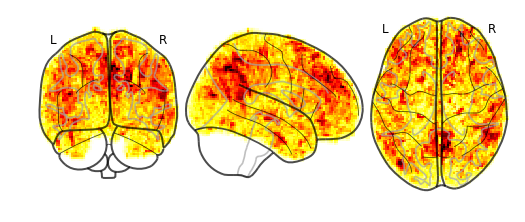

In [64]:
nl.plotting.plot_glass_brain(braindiff_i_mni)

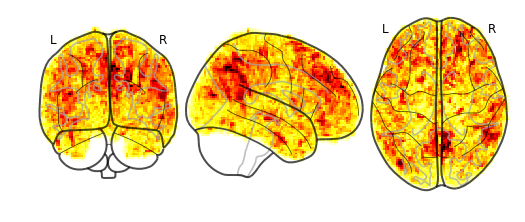

In [65]:
nl.plotting.plot_glass_brain(braindiff_d_mni)

# variance among participants' voxel activations immediate vs delayed

In [29]:
# avg_i_traj_brain = np.dot(avg_participant_trajectories['atlep1'], episode_topic_voxweights['atlep1'])
# avg_d_traj_brain = np.dot(avg_participant_trajectories['delayed'], episode_topic_voxweights['atlep1'])

In [51]:
# imm_trajs = [traj for turkid, traj in participant_trajectories['atlep1']]
# #sub_activation_corrs_i = np.empty((59, 1466))

# for ix, sub_traj in enumerate(imm_trajs):
#     if ix > 48:
#         sub_vox_traj = np.dot(sub_traj, episode_topic_voxweights['atlep1'])
#         sub_activation_corrs_i[ix] = np.diag(1-cdist(avg_i_traj_brain, sub_vox_traj, metric='correlation'))

In [55]:
# del_trajs = [traj for turkid, traj in participant_trajectories['delayed']]
# sub_activation_corrs_d = np.empty((59, 1466))

# for ix, sub_traj in enumerate(del_trajs):
#     sub_vox_traj = np.dot(sub_traj, episode_topic_voxweights['atlep1'])
#     sub_activation_corrs_d[ix] = np.diag(1-cdist(avg_d_traj_brain, sub_vox_traj, metric='correlation'))

In [73]:
# ribbon(sub_activation_corrs_i.T, color='red', label='Immediate')
# ribbon(sub_activation_corrs_d.T, color='skyblue', label='Delayed')
# plt.xlim((0,1466))
# plt.title('Across-participant activation variance', fontsize=16)
# plt.xlabel('Timepoint', fontsize=14)
# plt.ylabel('Mean brain state correlation', fontsize=14)
# plt.legend(loc=3, fontsize=14)
# plt.tight_layout()
# plt.savefig(brainfig_dir+'immediate-delayed-variance-corr.pdf')

## basic differences between immediate and delay

In [106]:
atl1_events = episode_events['atlep1']
atl1_topic_voxweights = episode_topic_voxweights['atlep1']

sub_imm_del_brains = np.empty((len(participant_events['atlep1']), 37226))
sub_del_imm_brains = np.empty((len(participant_events['atlep1']), 37226))

for i, (turkid1, imm_events) in enumerate(participant_events['atlep1']):
    
    # get sid and session 2 turkid
    sid, turkid2 = next((sid, id_maps[sid]['session 2']) for sid in id_maps.keys() 
                        if id_maps[sid]['session 1'] == turkid1)
    
    # get delayed recall events
    del_events = next(d_evs for tid, d_evs in participant_events['delayed'] if tid == turkid2)
    
    # get immediate and delayed event mappings
    imm_mappings = next(ms for tid, ms in event_mappings['atlep1'] if tid == turkid1)
    del_mappings = next(ms for tid, ms in event_mappings['delayed'] if tid == turkid2)
    
    # index mask for events recalled both immediately and after delay
    inboth_ix = np.unique(imm_mappings[np.isin(imm_mappings, del_mappings)])
    
    if any(inboth_ix):
        del_imm_brains = np.empty((inboth_ix.shape[0], 37226))
        imm_del_brains = np.empty((inboth_ix.shape[0], 37226))
        # find best immediate and delayed recall event for each recalled episode event
        for ix, m in enumerate(inboth_ix):
            imm_options = imm_events[np.where(imm_mappings == m)]
            del_options = del_events[np.where(del_mappings == m)]
            
            best_iev = imm_options[np.argmax(1-cdist(np.atleast_2d(imm_options), np.atleast_2d(atl1_events[m]), 
                         'correlation'))]
            best_dev = del_options[np.argmax(1-cdist(np.atleast_2d(del_options), np.atleast_2d(atl1_events[m]), 
                         'correlation'))]
            
            # compute difference between topic vectors
            del_not_imm = best_dev - best_iev
            imm_not_del = best_iev - best_dev
            
            # get brain map of activation differences
            del_imm_brains[ix] = np.dot(del_not_imm, atl1_topic_voxweights)
            imm_del_brains[ix] = np.dot(imm_not_del, atl1_topic_voxweights)
            
        # get average brain map of differences for participant
        sub_del_imm_brains[i] = del_imm_brains.mean(axis=0)
        sub_imm_del_brains[i] = imm_del_brains.mean(axis=0)
        
# average across participants
avg_del_imm_brain = sub_del_imm_brains.mean(axis=0)
avg_imm_del_brain = sub_imm_del_brains.mean(axis=0)

In [109]:
avg_del_imm_vol = cortex.Volume(avg_del_imm_brain, 'S1', 'fullhead', mask=mask, cmap='RdBu_r')
avg_imm_del_vol = cortex.Volume(avg_imm_del_brain, 'S1', 'fullhead', mask=mask, cmap='RdBu_r')

In [111]:
# del_imm_brainmap = cortex.webgl.show(avg_del_imm_vol, overlays_visible=(None, None))

Started server on port 24427


In [115]:
# del_imm_brainmap.getImage(brainfig_dir+'del_imm/del_imm_inflated_trilinear_left_medial.png')

[{}]

Stopping server


In [116]:
# imm_del_brainmap = cortex.webgl.show(avg_imm_del_vol, overlays_visible=(None, None))

Started server on port 32579


In [120]:
# imm_del_brainmap.getImage(brainfig_dir+'imm_del/imm_del_inflated_trilinear_right_medial.png')

[{}]

Stopping server


In [123]:
# avg_imm_del_mni = standardize_brainspace(avg_imm_del_vol)
# avg_del_imm_mni = standardize_brainspace(avg_del_imm_vol)
# nb.save(avg_imm_del_mni, braindata_dir+'imm_del_mni.nii.gz')
# nb.save(avg_del_imm_mni, braindata_dir+'del_imm_mni.nii.gz')